#**Hollywood Age Gap** - Beyond the Timeline: Mapping the Evolution of Casting Norms and Romantic Age Gaps in Cinema

## Milestone 2 - B1 Team 10
## Inchara Ashok


In [1]:
#Importing packages and libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Loading data
from google.colab import drive

#Mounting Google Drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/BA820 - Project/age_gaps (1).csv'

# Read the CSV into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows
print(df.head(3))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
           movie_name  release_year       director  age_difference  \
0    Harold and Maude          1971      Hal Ashby              52   
1               Venus          2006  Roger Michell              50   
2  The Quiet American          2002  Phillip Noyce              49   

   couple_number   actor_1_name     actor_2_name character_1_gender  \
0              1    Ruth Gordon         Bud Cort              woman   
1              1  Peter O'Toole  Jodie Whittaker                man   
2              1  Michael Caine   Do Thi Hai Yen                man   

  character_2_gender actor_1_birthdate actor_2_birthdate  actor_1_age  \
0                man        1896-10-30        1948-03-29           75   
1              woman        1932-08-02        1982-06-03           74   
2              woman        1933-03-14        1982-10-01           69   

   actor_2_a

## 1. Analysing the gap between male and female actors by decade

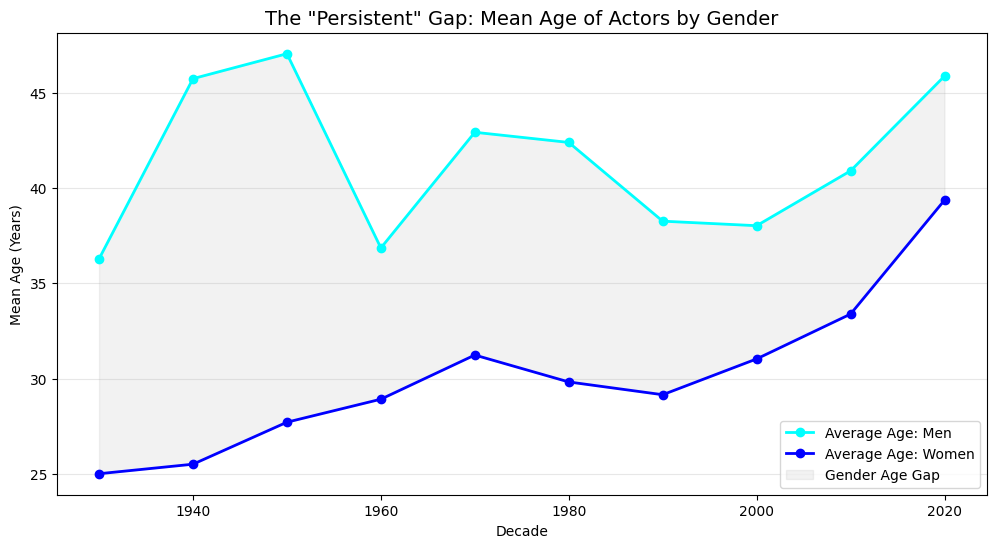

In [3]:
#Sorting release years into decades for easy interpretation
df['decade'] = (df['release_year'] // 10) * 10

#Combining all males and females from 'Actor1' and 'Actor2' titles into 2 gender categories
males = df[df['character_1_gender'] == 'man'][['decade', 'actor_1_age']].rename(columns={'actor_1_age': 'age'})
males = pd.concat([males, df[df['character_2_gender'] == 'man'][['decade', 'actor_2_age']].rename(columns={'actor_2_age': 'age'})])

females = df[df['character_1_gender'] == 'woman'][['decade', 'actor_1_age']].rename(columns={'actor_1_age': 'age'})
females = pd.concat([females, df[df['character_2_gender'] == 'woman'][['decade', 'actor_2_age']].rename(columns={'actor_2_age': 'age'})])

#Calculating average age of male and female actors by decade
avg_male = males.groupby('decade')['age'].mean()
avg_female = females.groupby('decade')['age'].mean()

#Plotting the chart
plt.figure(figsize=(12, 6))
plt.plot(avg_male.index, avg_male.values, label='Average Age: Men', color='cyan', marker='o', linewidth=2)
plt.plot(avg_female.index, avg_female.values, label='Average Age: Women', color='blue', marker='o', linewidth=2)
plt.fill_between(avg_male.index, avg_female.values, avg_male.values, color='gray', alpha=0.1, label='Gender Age Gap')
plt.title('The "Persistent" Gap: Mean Age of Actors by Gender', fontsize=14)
plt.xlabel('Decade')
plt.ylabel('Mean Age (Years)')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

The shaded area between the male and female age lines represents the “gender age gap” in romantic casting, with a wider area indicating periods of pronounced inequality in which Hollywood paired older men with significantly younger women. When this shaded region narrows, it marks an inflection point, signaling a shift toward more peer-to-peer casting and a reduction in age disparity. Focusing on the female age line reveals a potential “glass ceiling” for actresses: when it remains flat around ages 25–30 while the male line continues to rise, it suggests a limited shelf life for women in romantic roles. An upward trend in the female line in later decades, such as the 2000s and 2010s, points to a structural change in which older women are increasingly cast as romantic leads. In contrast, the male age line often stays high or continues to increase, reflecting the “ageless” leading man phenomenon, where established male stars sustain romantic lead roles for decades while their female counterparts are more frequently replaced by younger actresses.

## 2. Did being couple 1 have an effect on the age gap between actors as compared to being the rest?


/tmp/ipython-input-3733452585.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Couple Type', y='age_difference', palette='mako', width=0.5)


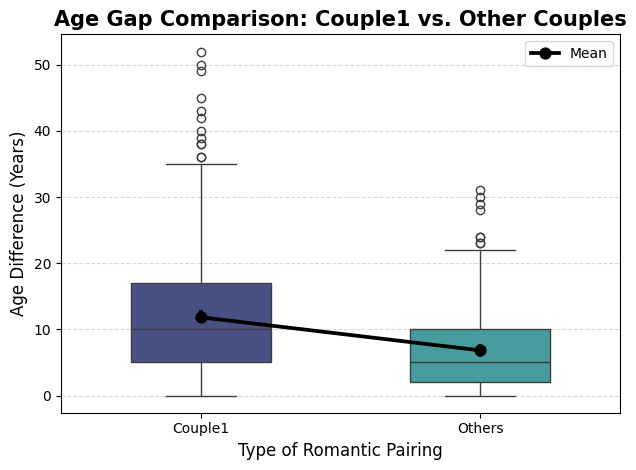

In [4]:
#Defining couple1 v/s other couples
df['Couple Type'] = df['couple_number'].apply(lambda x: 'Couple1' if x == 1 else 'Others')

#Creating visualization
sns.boxplot(data=df, x='Couple Type', y='age_difference', palette='mako', width=0.5)

#Adding the mean point
sns.pointplot(data=df, x='Couple Type', y='age_difference',
              estimator='mean', color='black', markers='o', label='Mean')

#Formatting chart
plt.title('Age Gap Comparison: Couple1 vs. Other Couples', fontsize=15, fontweight='bold')
plt.ylabel('Age Difference (Years)', fontsize=12)
plt.xlabel('Type of Romantic Pairing', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

When comparing Couple 1 (the pair with the largest age gap) to other couples in a film, the mean age gap reveals whether extreme age disparity is an intentional casting choice for specific roles. If the mean for Couple 1 is noticeably higher, it suggests that the primary age disparity in a film is not a random occurrence but a specific privilege often reserved for the most prominent stars. If the means were similar, it would indicate that age gaps are distributed more evenly across all roles; however, a significantly higher mean for Couple 1 confirms that "star bias" often manifests as a singular, large age gap at the top of the casting sheet.

The outliers in the Couple 1 category could be strong evidence of Star Bias. They represent movies where a high-profile veteran actor is paired with a much younger costar, resulting in an age difference (often 25–40+ years) that is not seen in the rest of the film's cast.

## 3. Percentage of movies that violates the 'half the age plus seven' rule

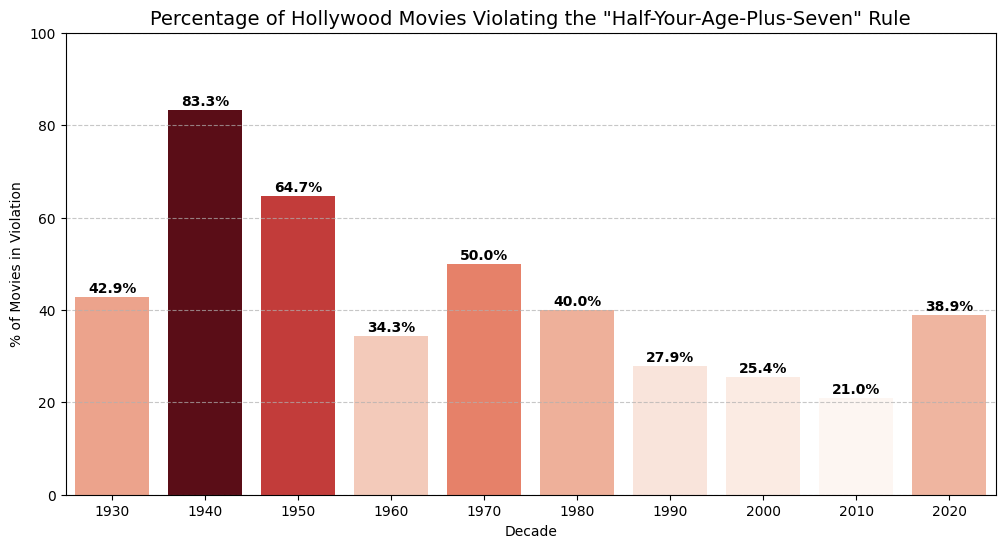

In [5]:
#Identifying the older and younger partner ages
df['older_age'] = df[['actor_1_age', 'actor_2_age']].max(axis=1)
df['younger_age'] = df[['actor_1_age', 'actor_2_age']].min(axis=1)

#Applying the rule --> (Older / 2) + 7
df['rule_threshold'] = (df['older_age'] / 2) + 7

#Flagging when rule is being violated
df['is_violation'] = df['younger_age'] < df['rule_threshold']

#Grouping by decade and calculating percentages
violation_stats = df.groupby('decade')['is_violation'].mean() * 100
violation_stats = violation_stats.reset_index(name='percent_violation')

#Plotting bar chart
plt.figure(figsize=(12, 6))
plot = sns.barplot(
    data=violation_stats,
    x='decade',
    y='percent_violation',
    hue='percent_violation',  # This tells seaborn to color based on the value
    palette='Reds',           # Highest values will be the darkest red
    dodge=False,              # Keeps bars centered
    legend=False
)

plt.title('Percentage of Hollywood Movies Violating the "Half-Your-Age-Plus-Seven" Rule', fontsize=14)
plt.ylabel('% of Movies in Violation')
plt.xlabel('Decade')
plt.ylim(0, 100) # Percentage scale
plt.grid(axis='y', linestyle='--', alpha=0.7)

#Adding percentage on top of each bar
for i, val in enumerate(violation_stats['percent_violation']):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.show()

Across the timeline, the chart reveals clear shifts in how frequently extreme age-gap pairings occurred. The highest bars appear during the 1940s and 1950s, often exceeding 40–50%, reflecting the Golden Age of the Studio System, when pairing older male stars with very young actresses faced little social or industrial resistance. A sharp decline emerges in the late 1960s and 1970s, marking a mid-century inflection point associated with the rise of New Hollywood. As films became more socially conscious and grounded in realism, casting choices increasingly mirrored peer-aged relationships, signaling a cultural shift away from fantasy-driven pairings. In the 2000s through the 2020s, violation rates reach their lowest levels, though they never fall to zero. This indicates that while such pairings are no longer normative, they persist as deliberate, exceptional choices—often tied to major stars or specific genres—rather than industry-wide trends. The color intensity helps with this interpretation: darker reds denote decades when extreme age gaps were systemic, while lighter tones indicate periods when they became marginal and increasingly confined to the fringes of cinema.

# Clustering Algorithms

## Elbow Method

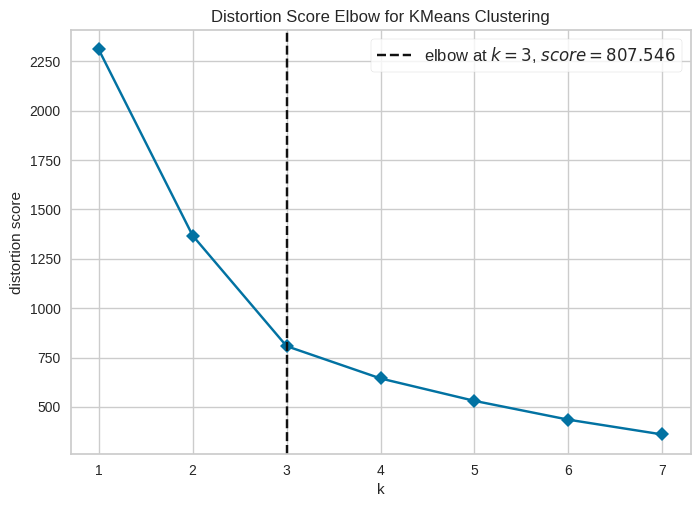

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer

#Standardizing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['release_year', 'age_difference']])

#Finding the Elbow
clustering = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(
    clustering,
    k=(1, 8),
    metric='distortion',
    timings=False,
    random_state=42
)

#Fitting the data to the visualizer
visualizer.fit(X_scaled)
visualizer.show()

#Fitting the optimal K (using 3 based on the findings)
final_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df['era_cluster'] = final_model.fit_predict(X_scaled)

The elbow in the distortion score plot occurs at k=3, where the curve shows its strongest change in curvature. From k=1 to k=3, the distortion score drops sharply, indicating a substantial improvement in cluster cohesion as the data move from one broad group to three distinct ones. Beyond k=3, the curve flattens, meaning additional clusters offer diminishing returns and mainly subdivide existing patterns without adding meaningful structure. Because clustering is based on release year and age difference, this result suggests three historically distinct casting regimes in Hollywood, likely representing a "Classic" era characterized by older films and large age gaps, a "Transitional" period with more moderate gaps as norms shifted, and a "Modern" era marked by consistently lower age differences. The minimal additional improvement beyond k=3 reinforces that k=3 is the most interpretable choice.

## Silhouette Score

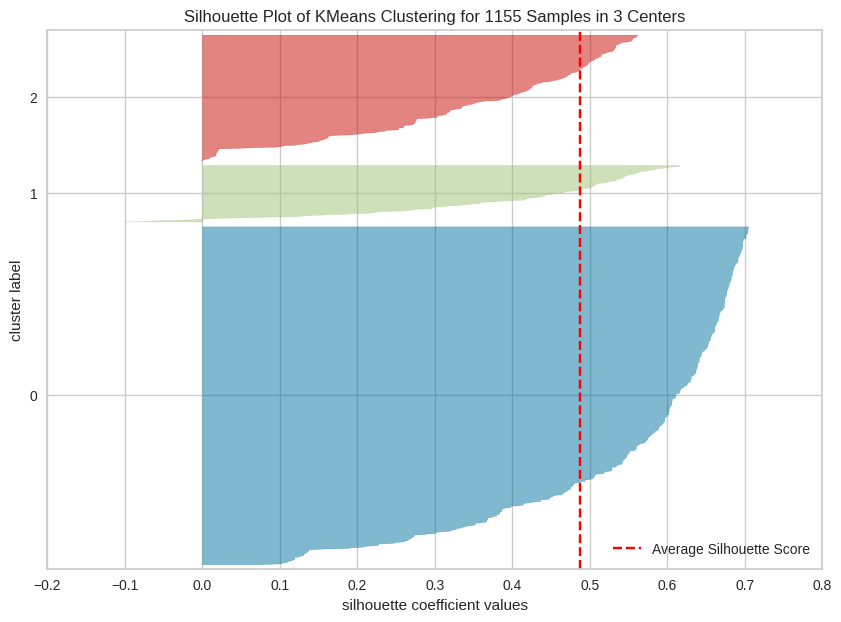

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1155 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [7]:
from sklearn.cluster import KMeans
# Using release_year and age_difference to find temporal regimes
X = df[['release_year', 'age_difference']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Silhouette Visualization using Yellowbrick
from yellowbrick.cluster import SilhouetteVisualizer

# Checking K=3, which appeared to be a strong candidate in the Elbow plot
model = KMeans(n_clusters=3, random_state=42, n_init=10)
visualizer = SilhouetteVisualizer(model, colors='yellowbrick', timings=False)

plt.figure(figsize=(10, 7))
visualizer.fit(X_scaled)
visualizer.show()

The average silhouette score of approximately 0.49 (shown by the red dashed line) indicates a moderate but meaningful cluster structure: the historical regimes are distinguishable, though some overlap in casting patterns remains. Cluster 0 is the largest and most stable group, with most observations scoring well above the average, suggesting strong internal consistency in year–age-gap behavior. Cluster 1 is more mixed, with a small negative tail indicating a few misfit films whose age gaps and release years do not align cleanly with a single regime. Cluster 2 performs well overall and largely exceeds the average silhouette score, capturing a distinct and cohesive modern pattern. Interpreted historically, these clusters align with three casting regimes: a consistent “Classic” era with traditional age-gap norms, a “Transitional” period marked by variability as norms shifted, and a “Modern” era in which age-gap patterns stabilize around a newer, narrower standard.


## Mapping clusters to historical periods

In [8]:
#Grouping by cluster to find the time boundaries
era_boundaries = df.groupby('era_cluster')['release_year'].agg(['min', 'max', 'count', 'mean']).sort_values(by='min')

#Renaming columsn for better interpretation
era_boundaries.columns = ['Start Year', 'End Year', 'Movie Count', 'Avg Release Year']
print(era_boundaries)

             Start Year  End Year  Movie Count  Avg Release Year
era_cluster                                                     
1                  1935      1984          126       1961.968254
2                  1971      2022          279       2004.720430
0                  1982      2022          750       2005.864000


In [9]:
from sklearn.metrics import silhouette_samples

#Calculating scores for every individual movie
scores = silhouette_samples(X_scaled, df['era_cluster'])

#Adding them to your dataframe
df['silhouette_score'] = scores

#Finding the 'Green Cluster' negatives (assuming green is Cluster 1)
anomalies = df[(df['era_cluster'] == 1) & (df['silhouette_score'] < 0)]

print(anomalies[['movie_name', 'release_year', 'age_difference']])

                               movie_name  release_year  age_difference
99                              Moonraker          1979              24
134                    For Your Eyes Only          1981              21
203                             Octopussy          1983              18
212                              Scarface          1983              18
425  Indiana Jones and the Temple of Doom          1984              11
497   The Best Little Whorehouse in Texas          1982              10
541               Raiders of the Lost Ark          1981               9


Several negative-silhouette films highlight meaningful exceptions to broader casting trends rather than noise. First, a “regressive casting” pattern appears in Roger Moore–era James Bond films (Moonraker, For Your Eyes Only, Octopussy), which exhibit very large age gaps despite being released during the transitional late-1970s/early-1980s period. These films follow Golden Age studio norms—older male lead paired with a much younger female lead—showing how a long-running franchise resisted industry-wide change. Second, the early 1980s emerge as a point of tension, with high-gap films (Bond entries) coexisting alongside lower-gap films like Raiders of the Lost Ark and Temple of Doom. This split reflects a battleground decade in which old and new casting norms overlapped, causing some films to sit on the fringes between clusters. Finally, star-driven vehicles such as Scarface and The Best Little Whorehouse in Texas reveal the influence of star power: major actors could override emerging norms, producing age gaps inconsistent with their era. In this sense, negative silhouette scores signal structurally meaningful anomalies driven by franchises and star power, not clustering failure.